In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
housing = fetch_california_housing()
x=housing.data
y=housing.target
print(x)
print(y)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16512, 8) (4128, 8) (16512,) (4128,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:2])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]]


In [ ]:
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
print(lasso)

lr.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)


Lasso(alpha=0.1)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
print("Predicted for : ",X_test_scaled[:1])
print("Linear Regression : ",y_pred_lr[:1])
print("Ridge Regression : ",y_pred_ridge[:1])
print("Lasso Regression : ",y_pred_lasso[:1])

Predicted for :  [[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
   0.1951      0.28534728]]
Linear Regression :  [0.71912284]
Ridge Regression :  [0.71947224]
Lasso Regression :  [1.21842882]


In [ ]:
print("Linear Coeffs:", lr.coef_)
print("Ridge Coeffs:", ridge.coef_)
print("Lasso Coeffs:", lasso.coef_)

Linear Coeffs: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Ridge Coeffs: [ 0.85432679  0.12262397 -0.29421036  0.33900794 -0.00228221 -0.04083302
 -0.89616759 -0.86907074]
Lasso Coeffs: [ 0.71059779  0.1064527  -0.          0.         -0.         -0.
 -0.01146856 -0.        ]


In [ ]:
print(f"\nLinear Regression MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"Ridge MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"Lasso MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")


Linear Regression MSE: 0.5559
Ridge MSE: 0.5559
Lasso MSE: 0.6796


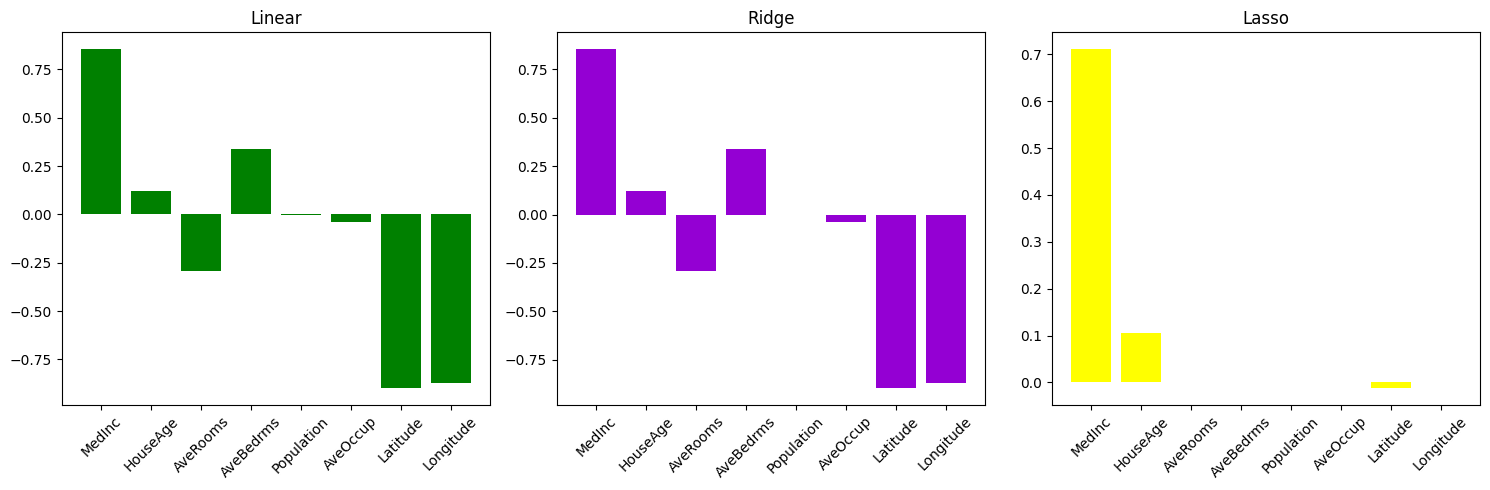

In [ ]:
plt.figure(figsize=(15, 5))
features = housing.feature_names
plt.subplot(1, 3, 1)
plt.bar(features, lr.coef_, color='green')
plt.xticks(rotation=45)
plt.title("Linear")
plt.subplot(1, 3, 2)
plt.bar(features, ridge.coef_, color='darkviolet')
plt.xticks(rotation=45)
plt.title("Ridge")
plt.subplot(1, 3, 3)
plt.bar(features, lasso.coef_, color='yellow')
plt.xticks(rotation=45)
plt.title("Lasso")
plt.tight_layout()
plt.show()